In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy import ndimage


In [2]:
nc_path = Path("/Users/nataliaefremova/Documents/ai4boundaries/data/sentinel2/images/AT/AT_3349_S2_10m_256.nc")

print(nc_path)
print("Exists:", nc_path.exists())

/Users/nataliaefremova/Documents/ai4boundaries/data/sentinel2/images/AT/AT_3349_S2_10m_256.nc
Exists: True


In [3]:
# open the NetCDF file and inspect its structure

ds = xr.open_dataset(nc_path)

ds

/Users/nataliaefremova/miniforge3/envs/cloudcasting311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


<xarray.Dataset> Size: 8MB
Dimensions:      (time: 6, y: 256, x: 256)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-03-01 2019-04-01 ... 2019-08-01
  * y            (y) float64 2kB 2.678e+06 2.678e+06 ... 2.675e+06 2.675e+06
  * x            (x) float64 2kB 4.466e+06 4.466e+06 ... 4.469e+06 4.469e+06
Data variables:
    B2           (time, y, x) float32 2MB ...
    B3           (time, y, x) float32 2MB ...
    B4           (time, y, x) float32 2MB ...
    B8           (time, y, x) float32 2MB ...
    NDVI         (time, y, x) float32 2MB ...
    spatial_ref  int32 4B ...

In [4]:
# print dataset summary

print(ds)
print("\nData variables:")
print(list(ds.data_vars))

print("\nCoordinates:")
print(list(ds.coords))

print("\nDimensions:")
print(dict(ds.sizes))

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 6, y: 256, x: 256)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-03-01 2019-04-01 ... 2019-08-01
  * y            (y) float64 2kB 2.678e+06 2.678e+06 ... 2.675e+06 2.675e+06
  * x            (x) float64 2kB 4.466e+06 4.466e+06 ... 4.469e+06 4.469e+06
Data variables:
    B2           (time, y, x) float32 2MB ...
    B3           (time, y, x) float32 2MB ...
    B4           (time, y, x) float32 2MB ...
    B8           (time, y, x) float32 2MB ...
    NDVI         (time, y, x) float32 2MB ...
    spatial_ref  int32 4B ...

Data variables:
['B2', 'B3', 'B4', 'B8', 'NDVI', 'spatial_ref']

Coordinates:
['time', 'x', 'y']

Dimensions:
{'time': 6, 'y': 256, 'x': 256}


In [5]:
# quick value ranges

for var in ["B2", "B3", "B4", "B8", "NDVI"]:
    arr = ds[var]
    print(
        var,
        "shape:", arr.shape,
        "min:", float(arr.min(skipna=True)),
        "max:", float(arr.max(skipna=True)),
        "mean:", float(arr.mean(skipna=True)),
    )

B2 shape: (6, 256, 256) min: -9999.0 max: 11336.0 mean: 523.9541015625
B3 shape: (6, 256, 256) min: -9999.0 max: 9936.0 mean: 783.9319458007812
B4 shape: (6, 256, 256) min: -9999.0 max: 9752.0 mean: 664.52197265625
B8 shape: (6, 256, 256) min: -9999.0 max: 15185.0 mean: 2995.946044921875
NDVI shape: (6, 256, 256) min: -0.21617646515369415 max: 0.9991779923439026 mean: 0.6627127528190613


In [6]:
# select one time slice 

time_index = 0

ndvi = ds["NDVI"].isel(time=time_index)
red = ds["B4"].isel(time=time_index).where(ds["B4"].isel(time=time_index) != -9999)
green = ds["B3"].isel(time=time_index).where(ds["B3"].isel(time=time_index) != -9999)
blue = ds["B2"].isel(time=time_index).where(ds["B2"].isel(time=time_index) != -9999)
nir = ds["B8"].isel(time=time_index).where(ds["B8"].isel(time=time_index) != -9999)

print("Selected time:", str(ds.time.values[time_index]))
print("NDVI shape:", ndvi.shape)
print("NDVI min/max:", float(ndvi.min(skipna=True)), float(ndvi.max(skipna=True)))

Selected time: 2019-03-01T00:00:00.000000000
NDVI shape: (256, 256)
NDVI min/max: -0.21617646515369415 0.9990471601486206


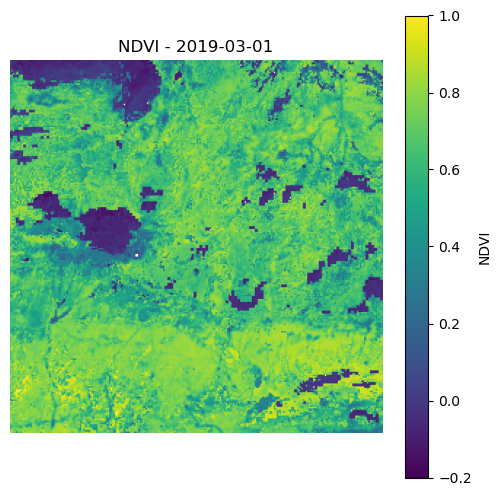

In [7]:
# display the selected NDVI tile

plt.figure(figsize=(6, 6))
plt.imshow(ndvi, cmap="viridis", vmin=-0.2, vmax=1.0)
plt.colorbar(label="NDVI")
plt.title(f"NDVI - {np.datetime_as_string(ds.time.values[time_index], unit='D')}")
plt.axis("off")
plt.show()

In [8]:
# apply Sobel to NDVI

ndvi_array = ndvi.values.astype(float)

# Replace missing values, if any, with the median NDVI value.
valid_median = np.nanmedian(ndvi_array)
ndvi_filled = np.where(np.isnan(ndvi_array), valid_median, ndvi_array)

sobel_x = ndimage.sobel(ndvi_filled, axis=1)
sobel_y = ndimage.sobel(ndvi_filled, axis=0)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

print("Sobel X range:", sobel_x.min(), sobel_x.max())
print("Sobel Y range:", sobel_y.min(), sobel_y.max())
print("Sobel magnitude range:", sobel_magnitude.min(), sobel_magnitude.max())

Sobel X range: -3.417008601129055 3.3967134580016136
Sobel Y range: -3.759405106306076 3.865931648761034
Sobel magnitude range: 0.0004455203469094411 4.3140973712588675


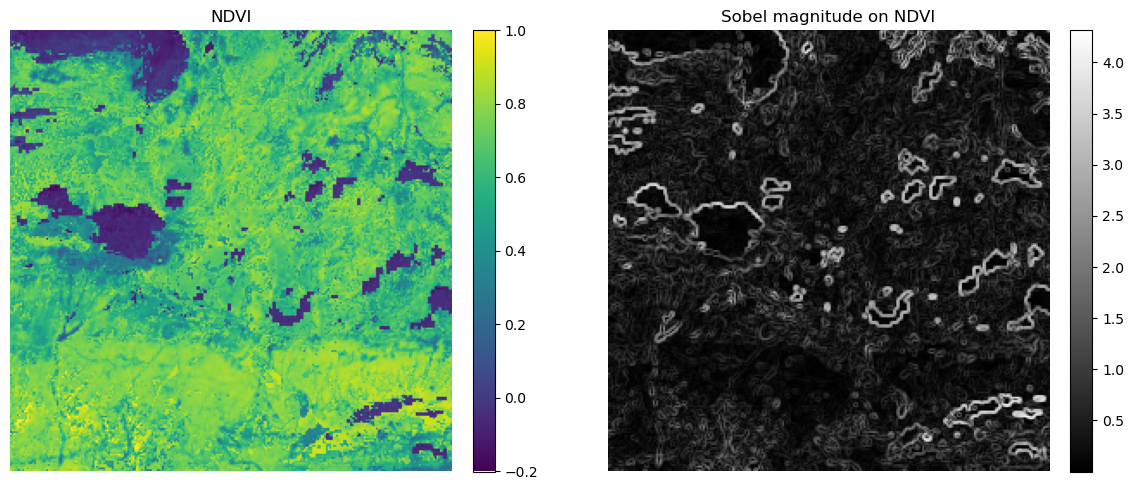

In [9]:
# visualize NDVI and Sobel edge magnitude

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(ndvi_filled, cmap="viridis", vmin=-0.2, vmax=1.0)
axes[0].set_title("NDVI")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(sobel_magnitude, cmap="gray")
axes[1].set_title("Sobel magnitude on NDVI")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


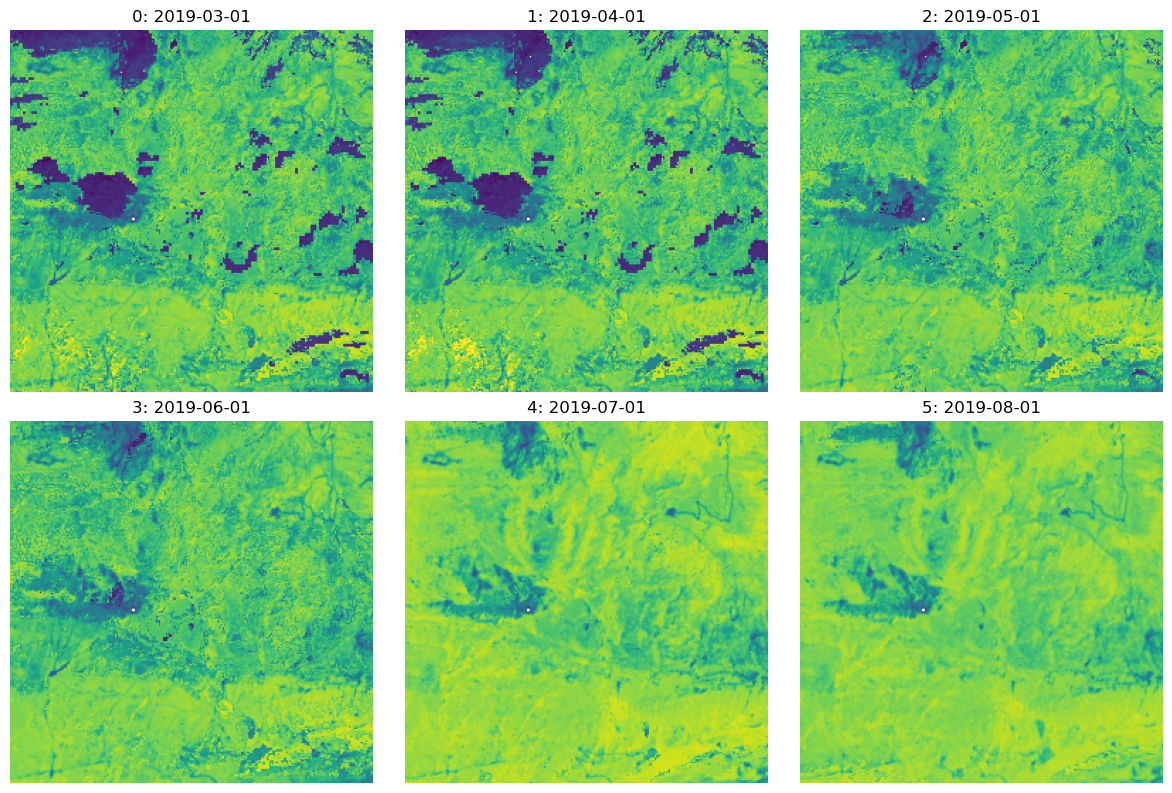

In [10]:
# preview all time slices

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, t in zip(axes.ravel(), range(ds.sizes["time"])):
    ndvi_t = ds["NDVI"].isel(time=t)
    date = np.datetime_as_string(ds.time.values[t], unit="D")
    
    ax.imshow(ndvi_t, cmap="viridis", vmin=-0.2, vmax=1.0)
    ax.set_title(f"{t}: {date}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# select a more field-like time slice

time_index = 4

ndvi = ds["NDVI"].isel(time=time_index)

ndvi_array = ndvi.values.astype(float)
valid_median = np.nanmedian(ndvi_array)
ndvi_filled = np.where(np.isnan(ndvi_array), valid_median, ndvi_array)

print("Selected time:", np.datetime_as_string(ds.time.values[time_index], unit="D"))
print("NDVI min/max:", np.nanmin(ndvi_array), np.nanmax(ndvi_array))

Selected time: 2019-07-01
NDVI min/max: -0.00871459674090147 0.9302481412887573


In [12]:
# Sobel on the July NDVI image

sobel_x = ndimage.sobel(ndvi_filled, axis=1)
sobel_y = ndimage.sobel(ndvi_filled, axis=0)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

print("Sobel X range:", sobel_x.min(), sobel_x.max())
print("Sobel Y range:", sobel_y.min(), sobel_y.max())
print("Sobel magnitude range:", sobel_magnitude.min(), sobel_magnitude.max())


Sobel X range: -2.1608016192913055 2.1245729327201843
Sobel Y range: -2.241042047739029 2.2739889323711395
Sobel magnitude range: 0.001005464638177478 2.8693707931742662


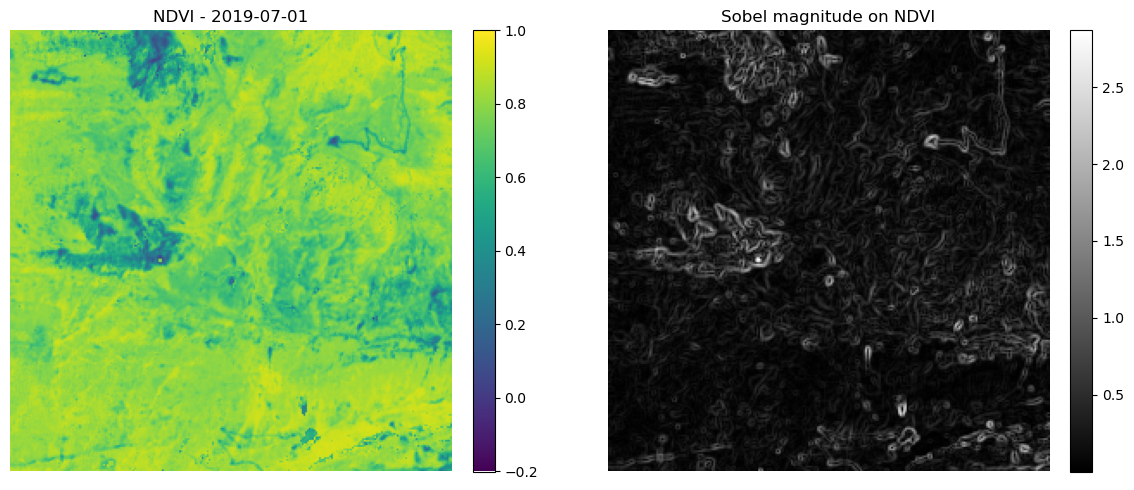

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

date = np.datetime_as_string(ds.time.values[time_index], unit="D")

im0 = axes[0].imshow(ndvi_filled, cmap="viridis", vmin=-0.2, vmax=1.0)
axes[0].set_title(f"NDVI - {date}")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(sobel_magnitude, cmap="gray")
axes[1].set_title("Sobel magnitude on NDVI")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [14]:
# make a true-color RGB image for the selected time

red = ds["B4"].isel(time=time_index).where(ds["B4"].isel(time=time_index) != -9999).values.astype(float)
green = ds["B3"].isel(time=time_index).where(ds["B3"].isel(time=time_index) != -9999).values.astype(float)
blue = ds["B2"].isel(time=time_index).where(ds["B2"].isel(time=time_index) != -9999).values.astype(float)

rgb = np.dstack([red, green, blue])

# Stretch each RGB channel independently for visualization.
rgb_stretched = np.zeros_like(rgb, dtype=float)

for i in range(3):
    channel = rgb[:, :, i]
    lo, hi = np.nanpercentile(channel, [2, 98])
    rgb_stretched[:, :, i] = np.clip((channel - lo) / (hi - lo), 0, 1)

# Replace any remaining NaNs with black.
rgb_stretched = np.nan_to_num(rgb_stretched, nan=0.0)

print("RGB shape:", rgb_stretched.shape)
print("RGB display range:", rgb_stretched.min(), rgb_stretched.max())


RGB shape: (256, 256, 3)
RGB display range: 0.0 1.0


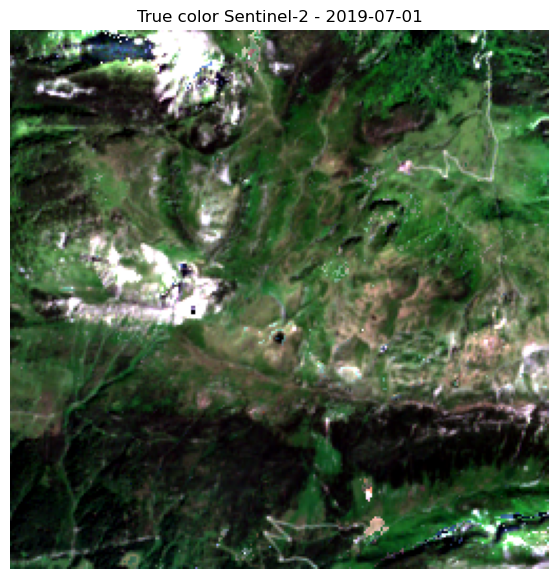

In [15]:
plt.figure(figsize=(7, 7))
plt.imshow(rgb_stretched)
plt.title(f"True color Sentinel-2 - {date}")
plt.axis("off")
plt.show()